# Applied Economics Software II — Week 6  
## Working with World Bank and Yahoo Finance Data in Python
### Prepared by
**Eren Eskicioğlu**
[GitHub](https://github.com/MrESKK)

## Installing the Required Package

The first step is to install the `wbgapi` package, which provides access to World Bank data directly from Python.


In [2]:
!pip install wbgapi yfinance geopandas openpyxl xlrd

## Importing the Required Libraries

The following libraries are used in the World Bank data section.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wbgapi as wb
import yfinance as yf
import geopandas as gpd
from google.colab import drive


## Connecting Google Drive

### Note:
If you upload this notebook to GitHub, the data files will not be inside the repository.  
Create your own Google Drive folder, upload the required files there, and paste your folder link below.

**Google Drive folder [link](https://drive.google.com/drive/folders/1bDZ6oaLCeiZmftQwD3P-G0LK-UjJ42Cx?usp=sharing)**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# Accessing Data from the World Bank Database

In this section, the notebook explores the basic tools available in the `wbgapi` library.  
These commands help inspect available series, search indicators, and retrieve country-level data.

## Checking the Loaded Package

This command prints the imported package object to confirm that it has been loaded successfully.

In [ ]:
print(wb)

<module 'wbgapi' from '/usr/local/lib/python3.12/dist-packages/wbgapi/__init__.py'>


## Viewing Help for Series Information

The following command displays help documentation for the `series` module.


In [ ]:
help(wb.series)

Help on module wbgapi.series in wbgapi:

NAME
    wbgapi.series - Access information about series in a database

FUNCTIONS
    Series(id='all', q=None, topic=None, db=None, name='SeriesName')
        Return a pandas Series by calling list

    get(id, db=None)
        Retrieve a specific series object

        Arguments:
            id:     the series identifier

            db:     database; pass None to access the global database

        Returns:
            a series object

        Example:
            print(wbgapi.series.get('SP.POP.TOTL')['value'])

    info(id='all', q=None, topic=None, db=None)
        Print a user report of series. This can be time consuming
        for large databases like the WDI if 'all' series are requested.

        Arguments:
            id:         a series identifier or list-like of identifiers

            q:          search string (on series name))

            topic:      topic ID or list-like

            db:         database; pass None to access t

## Listing Available Series

This step shows the available indicator series in the World Bank database.

In [ ]:
wb.series.info()

id,value
AG.CON.FERT.PT.ZS,Fertilizer consumption (% of fertilizer production)
AG.CON.FERT.ZS,Fertilizer consumption (kilograms per hectare of arable land)
AG.LND.AGRI.K2,Agricultural land (sq. km)
AG.LND.AGRI.ZS,Agricultural land (% of land area)
AG.LND.ARBL.HA,Arable land (hectares)
AG.LND.ARBL.HA.PC,Arable land (hectares per person)
AG.LND.ARBL.ZS,Arable land (% of land area)
AG.LND.CREL.HA,Land under cereal production (hectares)
AG.LND.CROP.ZS,Permanent cropland (% of land area)
AG.LND.EL5M.RU.K2,Rural land area where elevation is below 5 meters (sq. km)


## Example Indicator Codes

The following notes show example indicator codes related to exports and imports.


In [ ]:
# NE.EXP.GNFS.CD Exports of goods and services (current US$)
# NE.IMP.GNFS.CD Merchandise imports (current US$)

## Inspecting a Specific Series

This example displays information for the series `NE.EXP.GNFS.CD`, which represents exports of goods and services in current US dollars.


In [ ]:
wb.series.info("NE.EXP.GNFS.CD")

id,value
NE.EXP.GNFS.CD,Exports of goods and services (current US$)
,1 elements


## Viewing Selected Economies

This command displays information for Canada, the United States, and Mexico.


In [ ]:
wb.economy.info(["CAN","USA","MEX","TUR"])

id,value,region,incomeLevel
CAN,Canada,NAC,HIC
MEX,Mexico,LCN,UMC
TUR,Turkiye,ECS,UMC
USA,United States,NAC,HIC
,4 elements,,


## Searching for an Indicator by Keyword

This search looks for indicators related to final consumption expenditure.


In [ ]:
wb.search("final consumption expenditure")

ID,Name,Field,Value
URY,,SpecialNotes,...General Government final consumption expenditure includes Non-Profit Institutions Serving Households final concumption...
ID,Name,Field,Value
MDA~SH.XPD.EXTR.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.OOPC.TO.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.OOPC.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PCAP,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995. Changes for per capita values are due to...
MDA~SH.XPD.PCAP.PP.KD,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PRIV,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PRIV.CD,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PRIV.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....


## Downloading Sample Data
This step retrieves the selected indicators for the selected countries and stores the results in a DataFrame.


In [ ]:
series_list = ["NY.GDP.PCAP.CD", "NE.EXP.GNFS.CD"]
countries_list = ["TUR", "USA", "CAN"]
df_wb = wb.data.DataFrame(series_list, countries_list, mrv=5, columns="series")
df_wb


NE.EXP.GNFS.CD  NY.GDP.PCAP.CD
economy time                                  
CAN     YR2020    4.879907e+11    43537.839299
        YR2021    6.304782e+11    52886.661637
        YR2022    7.434954e+11    56256.800726
        YR2023    7.248061e+11    54220.328504
        YR2024    7.279205e+11    54340.347722
TUR     YR2020    2.108448e+11     8798.117917
        YR2021    2.944290e+11     9981.763984
        YR2022    3.532248e+11    10897.839786
        YR2023    3.642116e+11    13375.094728
        YR2024    3.746863e+11    15892.715729
USA     YR2020    2.151139e+12    63515.949181
        YR2021    2.555430e+12    70205.050916
        YR2022    3.017379e+12    76657.248884
        YR2023    3.052469e+12    81032.262118
        YR2024    3.193500e+12    84534.040784

## Turkey GDP per Capita

This section retrieves and displays Turkey's GDP per capita over time.
The data is organized as a time series and allows us to observe economic growth trends and fluctuations across years.

In [ ]:
df_tur_gdp_pc = wb.data.DataFrame(
    "NY.GDP.PCAP.CD",
    "TUR",
    time=range(1960, 2024),
    columns="series"
)
df_tur_gdp_pc


,NY.GDP.PCAP.CD
time,
YR1960,267.091208
YR1961,274.350891
YR1962,298.241021
YR1963,337.019857
YR1964,354.365541
...,...
YR2019,9395.233780
YR2020,8798.117917
YR2021,9981.763984


## Consumption and GDP

This section retrieves consumption and GDP data for Canada, the United States, and Turkey for the selected period.  
These two macroeconomic indicators are used to compare overall economic activity and household spending behavior across countries.

In [ ]:
series_list2 = ["NE.CON.TOTL.KD", "NY.GDP.MKTP.KD"]
countries_list2 = ["CAN", "USA", "TUR"]
df_macro = wb.data.DataFrame(series_list2, countries_list2, time=range(1990, 2025), columns="series")
df_macro.head()

NE.CON.TOTL.KD  NY.GDP.MKTP.KD
economy time                                  
CAN     YR1990    6.806526e+11    8.778242e+11
        YR1991    6.798938e+11    8.594684e+11
        YR1992    6.889053e+11    8.671217e+11
        YR1993    6.974915e+11    8.901672e+11
        YR1994    7.094251e+11    9.301718e+11

## Canada Example

This example focuses on Canada and presents the time-series behavior of consumption and GDP.  
The line graph helps visualize how both variables changed over time and whether they followed a similar trend.

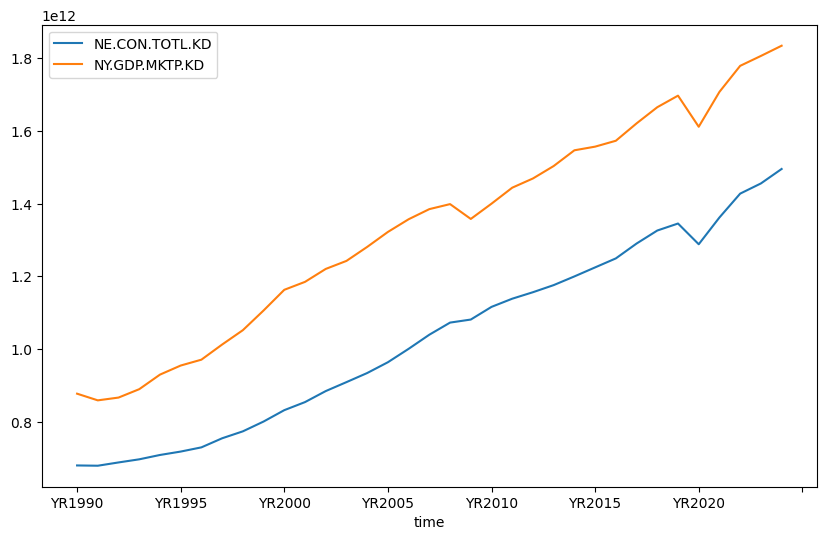

In [ ]:
df_canada = df_macro.loc["CAN"]
df_canada.plot(kind="line", figsize=(10,6))
plt.show()


## Canada Boxplot

This boxplot summarizes the distribution of Canada’s consumption and GDP values.  
It highlights the median, spread, and possible variation in the data, making it easier to compare the two series statistically.

<Axes: >

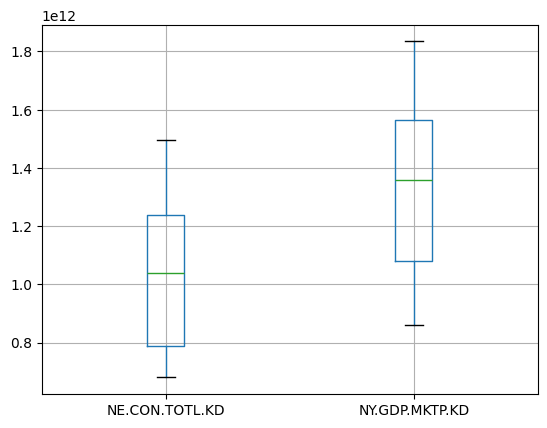

In [ ]:
df_canada.boxplot()

## Canada Scatter Plot

This scatter plot illustrates the relationship between GDP and consumption in Canada.  
It helps identify whether there is a positive association between economic output and total consumption.

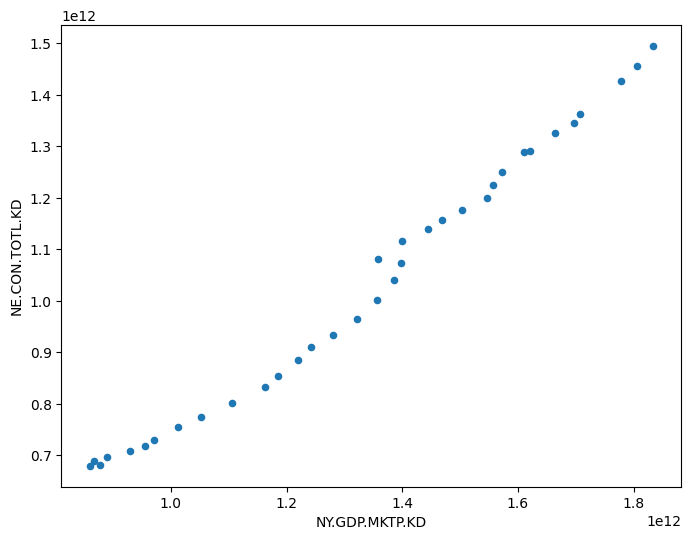

In [ ]:
df_canada.plot.scatter(x="NY.GDP.MKTP.KD", y="NE.CON.TOTL.KD", figsize=(8,6))
plt.show()

## The Consumption Function

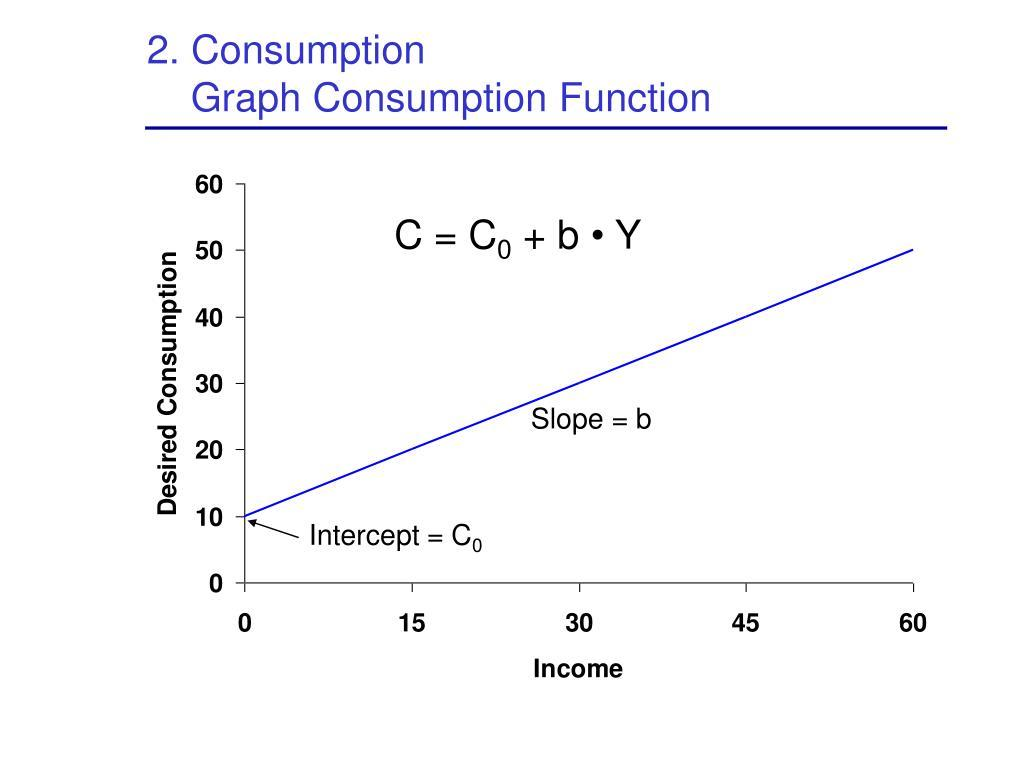

In [ ]:
import seaborn as sns

<Axes: xlabel='NY.GDP.MKTP.KD', ylabel='NE.CON.TOTL.KD'>

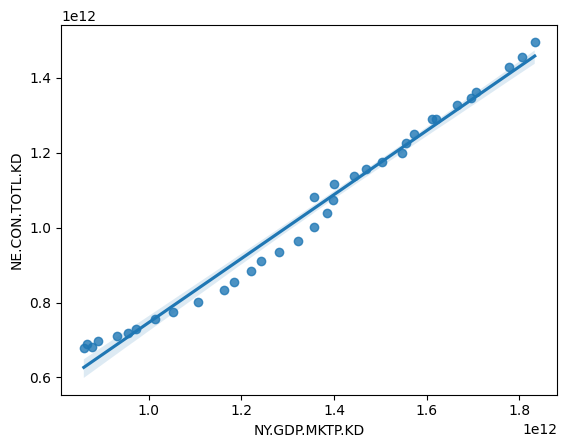

In [ ]:
x_dataa = df_canada[("NY.GDP.MKTP.KD")]
y_dataa = df_canada[("NE.CON.TOTL.KD")]

sns.regplot(x = x_dataa, y = y_dataa)

## matplotlib

This section uses the matplotlib library to visualize the relationship between consumption and GDP.  
The graph provides a simple way to observe trends and patterns in the data.
[mathplotlib](https://matplotlib.org/)

In [ ]:
from matplotlib import pyplot as plt

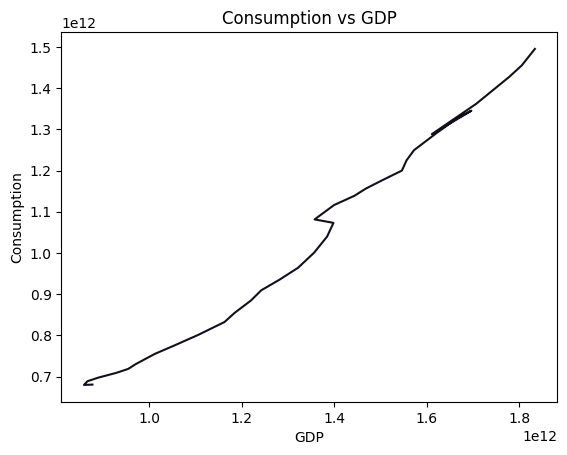

In [ ]:
plt.plot(x_dataa, y_dataa, color ="#150F1C")
#plt.plot(x_dataa,y_data) yeni bir çizgi eklemek için
plt.title("Consumption vs GDP")
plt.xlabel("GDP")
plt.ylabel("Consumption")
plt.show()

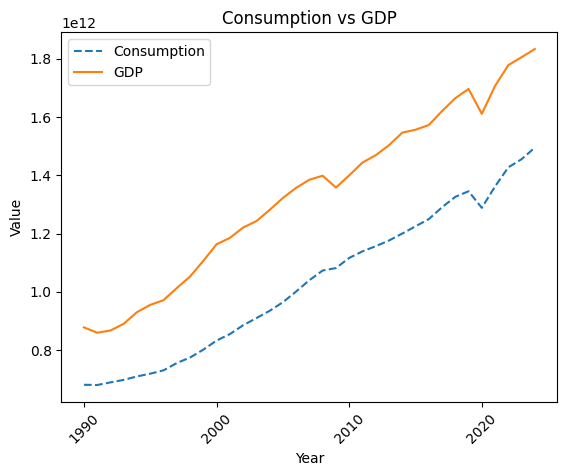

In [ ]:
from matplotlib.lines import lineStyles
consumption = df_canada['NE.CON.TOTL.KD']
gdp = df_canada['NY.GDP.MKTP.KD']
plt.plot(consumption, linestyle= "--")
plt.plot(gdp, linestyle= "-")
plt.legend(["Consumption", "GDP"])
plt.title("Consumption vs GDP")
plt.xlabel("Year")
plt.ylabel("Value")

years = consumption.index.str.replace("YR", "").astype(int)
plt.xticks(range(0, len(years), 10), years[::10], rotation=45)

plt.show()

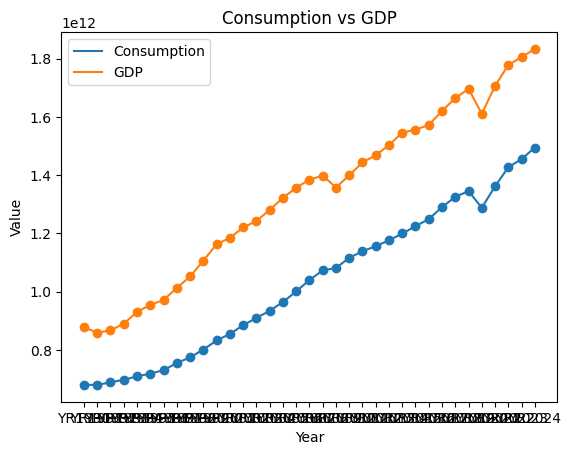

In [ ]:
plt.plot(consumption, linestyle="-")
plt.plot(gdp, linestyle="-")

# SCATTER EKLEME
plt.scatter(consumption.index, consumption)
plt.scatter(gdp.index, gdp)

plt.legend(["Consumption", "GDP"])
plt.title("Consumption vs GDP")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()

In [ ]:
import numpy as np

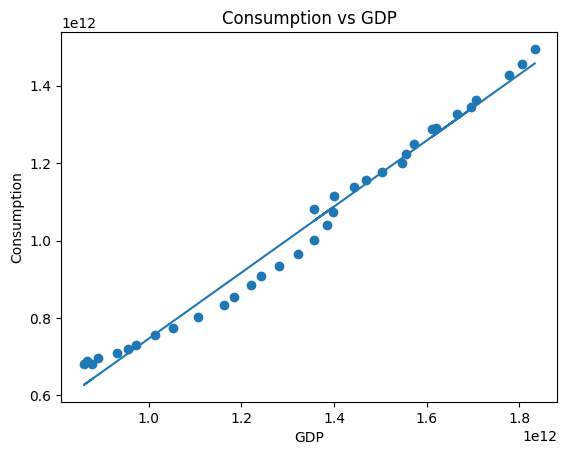

In [ ]:
gdp2 = df_canada[("NY.GDP.MKTP.KD")]
consumption2 = df_canada[("NE.CON.TOTL.KD")]

plt.scatter(gdp2, consumption2)

m, b = np.polyfit(gdp2, consumption2, 1)
plt.plot(gdp2, m * gdp2 + b)

plt.title("Consumption vs GDP")
plt.xlabel("GDP")
plt.ylabel("Consumption")
plt.show()

# Getting Stock Data from Yahoo Finance

In this section, stock price data is downloaded from Yahoo Finance and then displayed in table and chart form.

## Downloading Stock Price Data for US Companies

This code downloads daily stock data for Apple, Microsoft, Google, and Nvidia over the selected period.


In [ ]:
stock_symbols = ["AAPL", "MSFT", "GOOGL", "NVDA"]
data = yf.download(stock_symbols, start="2015-01-01", end="2024-12-31")
data


/tmp/ipykernel_11086/34077244.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbols, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  4 of 4 completed


Price            Close                                            High  \
Ticker            AAPL       GOOGL        MSFT        NVDA        AAPL   
Date                                                                     
2015-01-02   24.214895   26.260456   39.767677    0.482985   24.682228   
2015-01-05   23.532715   25.760092   39.401993    0.474828   24.064278   
2015-01-06   23.534933   25.124348   38.823677    0.460432   23.794069   
2015-01-07   23.864944   25.050459   39.316936    0.459232   23.964612   
2015-01-08   24.781891   25.137737   40.473564    0.476507   24.839477   
...                ...         ...         ...         ...         ...   
2024-12-23  253.883118  193.734329  431.078827  139.624237  254.261043   
2024-12-24  256.797211  195.207520  435.119720  140.174072  256.807136   
2024-12-26  257.612732  194.699875  433.911407  139.884155  258.686881   
2024-12-27  254.201370  191.872925  426.404083  136.965118  257.294489   
2024-12-30  250.829803  190.359940  420.758667  137.444946  252.122744   

Price                                                  Low              \
Ticker           GOOGL        MSFT        NVDA        AAPL       GOOGL   
Date                                                                     
2015-01-02   26.570394   40.328983    0.486584   23.776355   26.177639   
2015-01-05   26.183096   39.742176    0.484425   23.346669   25.675294   
2015-01-06   25.846874   39.759186    0.476027   23.173912   25.070294   
2015-01-07   25.364860   39.512543    0.467869   23.632385   24.976075   
2015-01-08   25.166995   40.609638    0.479386   24.075355   24.548109   
...                ...         ...         ...         ...         ...   
2024-12-23  194.202168  433.455821  139.744193  252.072998  189.274935   
2024-12-24  195.207520  435.387152  141.853515  253.903002  192.888240   
2024-12-26  195.844577  436.714303  140.803867  256.230300  193.485488   
2024-12-27  194.421157  431.049140  138.974470  251.685117  189.772634   
2024-12-30  191.663909  423.452601  140.224034  249.387684  188.249685   

Price                                     Open                          \
Ticker            MSFT        NVDA        AAPL       GOOGL        MSFT   
Date                                                                     
2015-01-02   39.580578    0.475307   24.671153   26.411704   39.682632   
2015-01-05   39.333954    0.472668   23.984543   26.141440   39.436009   
2015-01-06   38.730126    0.459952   23.596948   25.811666   39.444515   
2015-01-07   38.687595    0.457792   23.743127   25.338083   39.104321   
2015-01-08   39.733662    0.464270   24.192743   24.869950   39.759175   
...                ...         ...         ...         ...         ...   
2024-12-23  428.682005  135.075725  253.385834  191.733569  432.554538   
2024-12-24  430.028995  138.604579  254.101927  193.943360  430.484578   
2024-12-26  432.445610  137.684879  256.787255  194.251934  434.872113   
2024-12-27  422.264149  134.665884  256.429191  194.052849  430.435086   
2024-12-30  417.856754  133.976082  250.859639  188.926564  421.976890   

Price                      Volume                                 
Ticker            NVDA       AAPL     GOOGL      MSFT       NVDA  
Date                                                              
2015-01-02    0.482985  212818400  26480000  27913900  113680000  
2015-01-05    0.482985  257142000  41182000  39673900  197952000  
2015-01-06    0.475547  263188400  54456000  36447900  197764000  
2015-01-07    0.463791  160423600  46918000  29114100  321808000  
2015-01-08    0.464510  237458000  73054000  29645200  283780000  
...                ...        ...       ...       ...        ...  
2024-12-23  136.235348   40858800  25675000  19152500  176053500  
2024-12-24  139.954143   23234700  10403300   7164500  105157000  
2024-12-26  139.654235   27237100  12046600   8194200  116205600  
2024-12-27  138.504623   42355300  18891400  18117700  170582600  
2024-12-30  134.78

## Extracting Closing Prices

The next step selects only the closing price columns from the downloaded dataset.

In [ ]:
df_close = data["Close"]
df_close.head()


Ticker,AAPL,GOOGL,MSFT,NVDA
Date,,,,
2015-01-02,24.214895,26.260456,39.767677,0.482985
2015-01-05,23.532715,25.760092,39.401993,0.474828
2015-01-06,23.534933,25.124348,38.823677,0.460432
2015-01-07,23.864944,25.050459,39.316936,0.459232
2015-01-08,24.781891,25.137737,40.473564,0.476507


## Plotting Closing Prices

The following charts visualize the closing prices of the selected stocks.

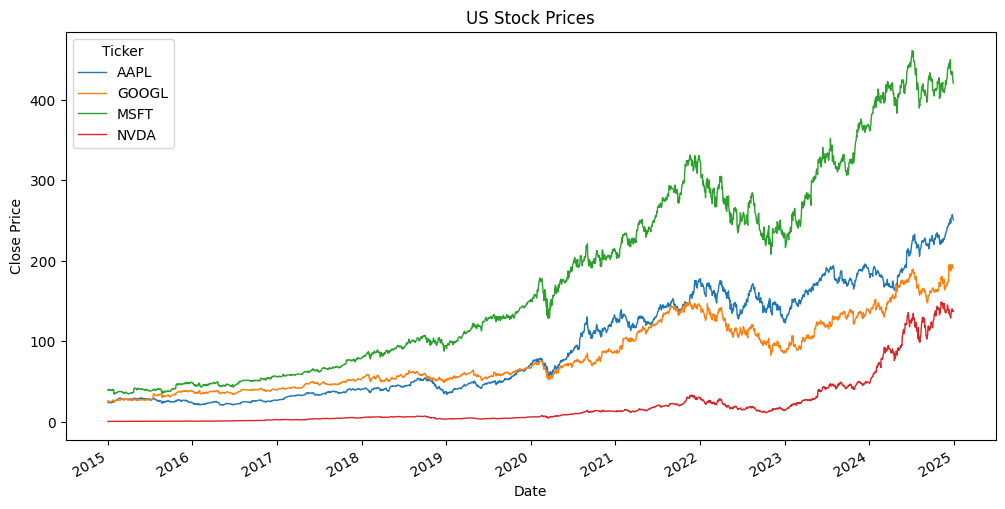

In [ ]:
df_close.plot(lw=1, figsize=(12,6), title="US Stock Prices")
plt.ylabel("Close Price")
plt.show()


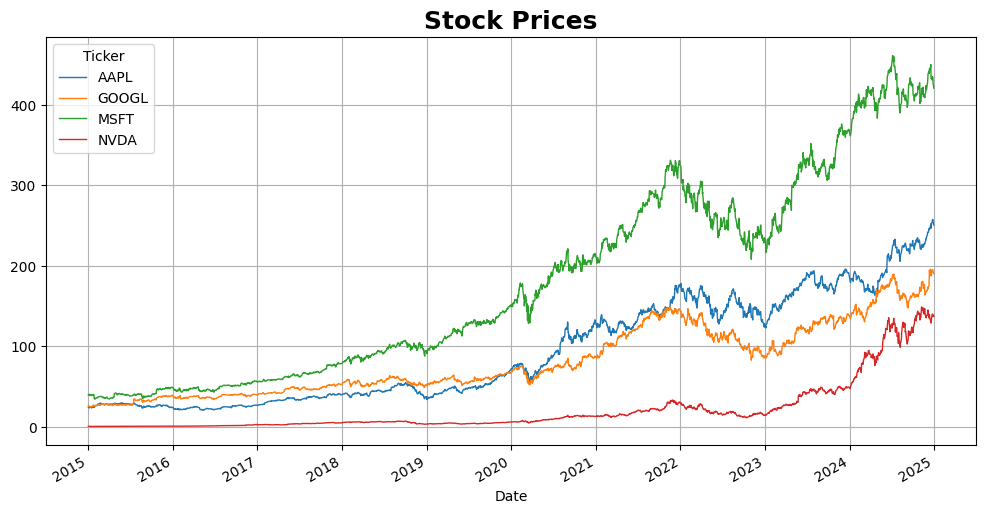

In [ ]:
ax = df_close.plot(lw=1,figsize=(12,6))
ax.set_title("Stock Prices", fontsize=18, fontweight="bold")
ax.grid(True)

## Creating a Scatter Plot

This example creates a scatter plot using Apple's opening prices.

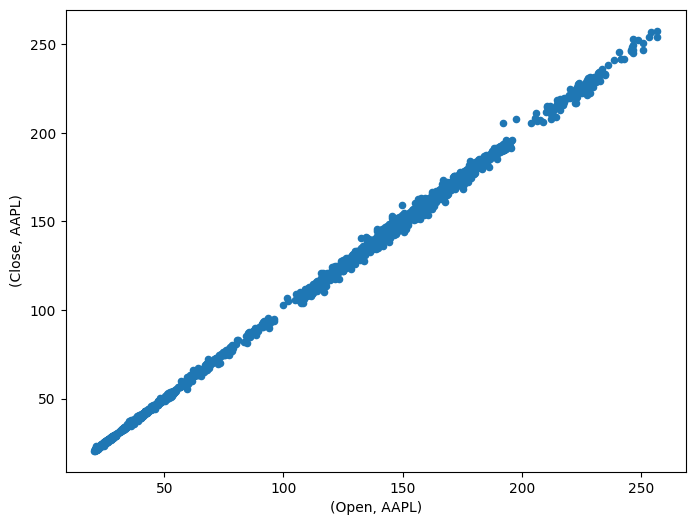

In [ ]:
data.plot.scatter(x=("Open","AAPL"), y=("Close","AAPL"), figsize=(8,6))
plt.show()


## Scatter Plot with a Regression Line

This example compares Apple's opening and closing prices and adds a fitted regression line.


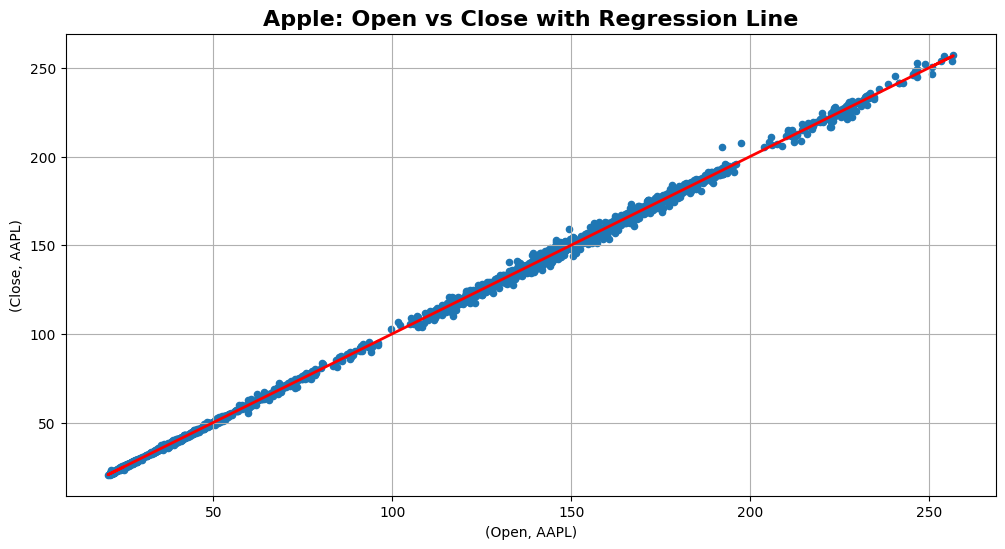

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ax = data.plot.scatter(x=("Open","AAPL"), y=("Close","AAPL"), figsize=(12,6))

x = data[("Open","AAPL")]
y = data[("Close","AAPL")]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red", linewidth=2)

plt.title("Apple: Open vs Close with Regression Line", fontsize=16, fontweight="bold")
plt.grid(True)
plt.show()

## Downloading Stock Price Data for Turkish Companies

This code downloads daily stock data for selected Borsa İstanbul companies.


In [ ]:
stock_symbols_tr = ["ASELS.IS", "THYAO.IS", "BIMAS.IS", "ARCLK.IS"]
data_tr = yf.download(stock_symbols_tr, start="2015-01-01", end="2024-12-31")
df_close_tr = data_tr["Close"]
df_close_tr.head()


/tmp/ipykernel_11086/2973758957.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_tr = yf.download(stock_symbols_tr, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  4 of 4 completed


Ticker,ARCLK.IS,ASELS.IS,BIMAS.IS,THYAO.IS
Date,,,,
2015-01-01,11.782551,1.419959,18.009247,9.407395
2015-01-02,11.821824,1.419959,17.991240,9.495315
2015-01-05,11.861101,1.431792,18.351423,9.964218
2015-01-06,11.939651,1.449541,18.495489,9.964218
2015-01-07,11.900375,1.449541,18.387442,9.817686


## Plotting Closing Prices for Turkish Stocks

The following chart visualizes the closing prices of the selected Turkish stocks.


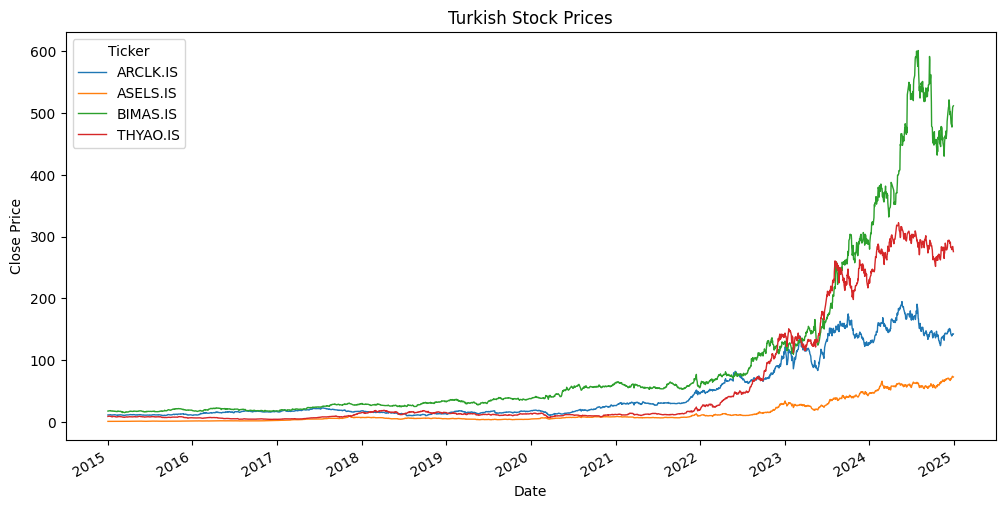

In [ ]:
df_close_tr.plot(lw=1, figsize=(12,6), title="Turkish Stock Prices")
plt.ylabel("Close Price")
plt.show()


# Analysis of Consumption and GDP
This assignment analyzes the relationship between consumption and GDP using macroeconomic data.
Different visualization techniques are applied to better understand trends, relationships, and distributions.

## World Map Data

In this section, population, income, and GDP per capita data are collected for countries worldwide.
These variables will be used to create global visualizations.

In [4]:
indicator_population = "SP.POP.TOTL"
indicator_income = "NY.GNP.PCAP.CD"
indicator_gdp_per_capita = "NY.GDP.PCAP.CD"

population_data = wb.data.DataFrame(indicator_population, time=2020).reset_index()
income_data = wb.data.DataFrame(indicator_income, time=2020).reset_index()
gdp_per_capita_data = wb.data.DataFrame(indicator_gdp_per_capita, time=2020).reset_index()


## Reading the World Shapefile

This section loads the world shapefile, which contains geographic boundaries of countries.
It is necessary for mapping and spatial visualization.

In [7]:
world = gpd.read_file("/content/drive/MyDrive/World_Countries/ne_110m_admin_0_countries.shp")
world.head()


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


## Editing Country Codes

Country codes are adjusted to ensure consistency between the dataset and the shapefile.
This step is required for accurate merging of data.

In [27]:
world["SOV_A3"] = world["SOV_A3"].replace({
    "US1": "USA",
    "FR1": "FRA",
    "GB1": "GBR",
    "DN1": "DNK",
    "CH1": "CHN",
    "AU1": "AUS",
    "NZ1": "NZL",
    "KA1": "KAZ",
    "IS1": "ISR",
    "CU1": "CUB",
    "NL1": "NLD",
    "FI1": "FIN",
    "SDS": "SSD"
})


## Merging the Data

In this step, the economic data is merged with the geographic data.
This allows us to link country-level indicators with their spatial representation.

In [28]:
world_population = world.merge(population_data, left_on="SOV_A3", right_on="economy", how="left")
world_income = world.merge(income_data, left_on="SOV_A3", right_on="economy", how="left")
world_gdp_per_capita = world.merge(gdp_per_capita_data, left_on="SOV_A3", right_on="economy", how="left")


## World Population Map

This map visualizes the distribution of population across countries.
It helps identify densely populated regions and global population patterns.

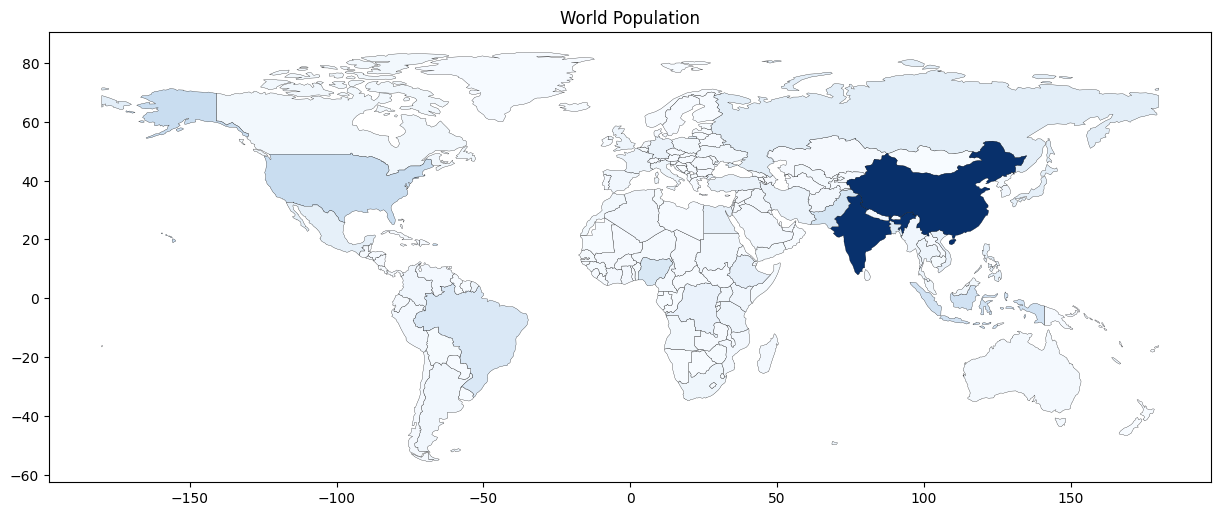

In [33]:
world_population.plot(
    column="SP.POP.TOTL",
    figsize=(15,8),
    cmap="Blues",
    edgecolor="black",
    linewidth=0.2
)
plt.title("World Population")
plt.show()

## World Income Map

This map shows income levels across countries.
It allows comparison of economic prosperity between different regions.

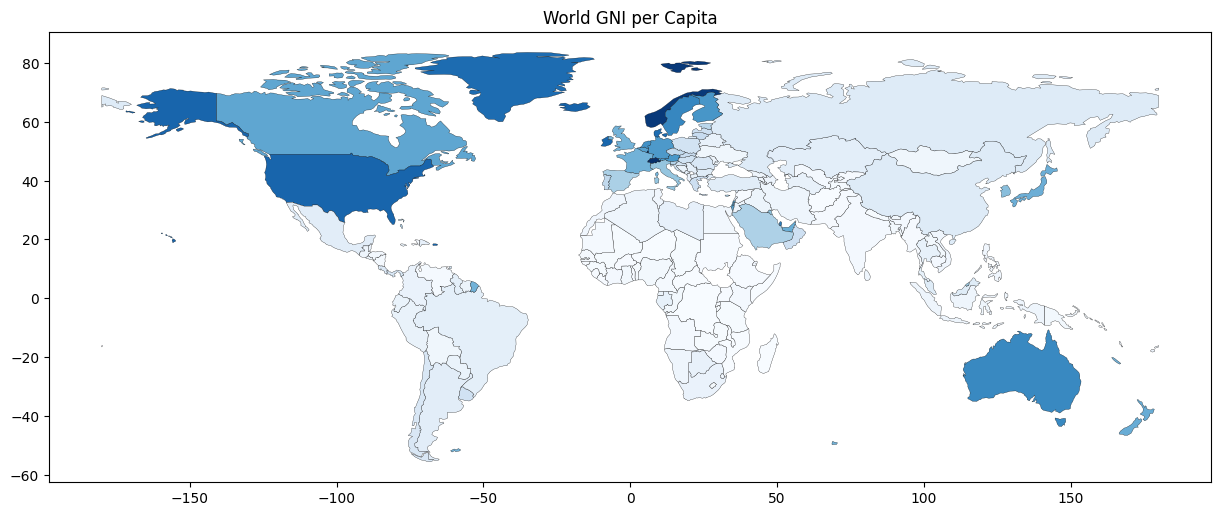

In [32]:
world_income.plot(
    column="NY.GNP.PCAP.CD",
    figsize=(15,8),
    cmap="Blues",
    edgecolor="black",
    linewidth=0.2
)
plt.title("World GNI per Capita")
plt.show()

## GDP per Capita Map

This map presents GDP per capita across countries.
It is used to compare living standards and economic development globally.

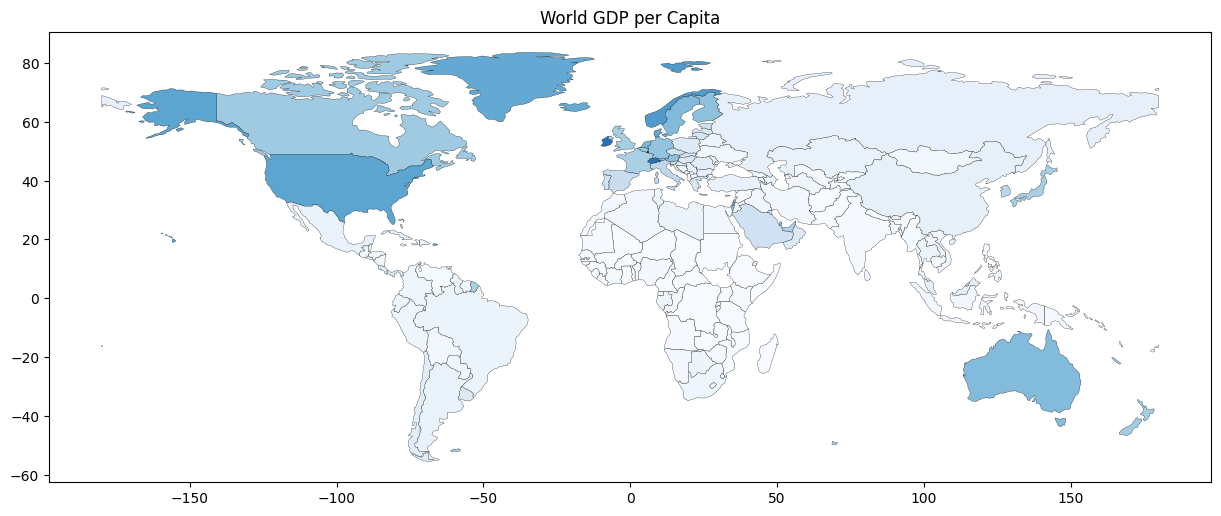

In [34]:
world_gdp_per_capita.plot(
    column="NY.GDP.PCAP.CD",
    figsize=(15,8),
    cmap="Blues",
    edgecolor="black",
    linewidth=0.2
)
plt.title("World GDP per Capita")
plt.show()

#Turkey Analysis
This section focuses on Turkey and analyzes regional data at the provincial level.
The aim is to examine differences in economic indicators across regions.

### Note:
For GitHub, upload the Turkey Excel file and the Turkey shapefile to your own Google Drive folder.  
Then update the file paths below.

In [59]:
!pip install geopandas xlrd openpyxl

In [60]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import unicodedata
import re
from google.colab import drive

In [61]:
excel_path = "/content/drive/MyDrive/deneme.xls"
shp_path = "/content/drive/MyDrive/tr_shp/tr_shpp"

## Turkey Economic Data

This dataset contains regional economic indicators for Turkey, including GDP per capita and population.
It will be used to analyze economic differences across provinces.

In [62]:
income_data = pd.read_excel(excel_path, header=None)
income_data.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,İl bazında kişi başına gayrisafi yurt içi hası...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Gross domestic product per capita by provinces...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,İstatistiki Bölge Birimleri Sınıflaması (3. Dü...,NaN,Kişi başına GSYH (TL) \n Per capita GDP (TRY),NaN,NaN,NaN,NaN,NaN,Kişi başına GSYH ($) \n Per capita GDP ($),NaN,NaN,NaN,NaN
3,NaN,NaN,2020,2021.000000,2022.00000,2023.000000,2024.000000,NaN,2020,2021.000000,2022.000000,2023.000000,2024.000000
4,TR,Türkiye,59116.041392,84635.463469,172921.67886,305569.784668,503075.557356,NaN,8397.339136,9423.609715,10434.136619,13007.620542,15325.125656


In [63]:
income_data = income_data.iloc[4:, [1, 12]]
income_data.columns = ["il_adi", "gsyh_kisi_basi"]
income_data = income_data.dropna()
income_data = income_data[income_data["il_adi"] != "Türkiye"]
income_data.head()

,il_adi,gsyh_kisi_basi
5,İstanbul,24451.609381
6,Tekirdağ,18406.453397
7,Edirne,12711.126014
8,Kırklareli,16187.589695
9,Balıkesir,14004.213734


## Turkey Geographic Data

This section loads the shapefile of Turkey, which contains the geographic boundaries of provinces.
It enables spatial visualization of regional data.

In [64]:
turkey = gpd.read_file(shp_path)
turkey.head()

,id,name,source,geometry
0,TR75,Ardahan,https://simplemaps.com,"POLYGON ((43.44043 41.10659, 43.37545 41.08993..."
1,TR08,Artvin,https://simplemaps.com,"POLYGON ((42.45103 41.43137, 42.46545 41.37362..."
2,TR73,Sirnak,https://simplemaps.com,"POLYGON ((43.36251 37.30391, 43.33615 37.32023..."
3,TR30,Hakkari,https://simplemaps.com,"POLYGON ((43.36251 37.30391, 43.37599 37.32475..."
4,TR76,IÄdir,https://simplemaps.com,"POLYGON ((44.45825 39.64252, 44.45778 39.6428,..."


## Cleaning Province Names

Province names are standardized to ensure consistency between datasets.
This step is necessary for accurate data merging.

In [65]:
def temizle_isim(x):
    x = str(x).upper().strip()
    x = x.replace("Ç", "C")
    x = x.replace("Ğ", "G")
    x = x.replace("İ", "I")
    x = x.replace("Ö", "O")
    x = x.replace("Ş", "S")
    x = x.replace("Ü", "U")
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    x = re.sub(r"[^A-Z ]", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

In [66]:
income_data["il_adi"] = income_data["il_adi"].apply(temizle_isim)
turkey["name"] = turkey["name"].apply(temizle_isim)

## Fixing Different Names

In [67]:
isim_duzelt = {
    "AANAKKALE": "CANAKKALE",
    "AANKIRI": "CANKIRI",
    "AORUM": "CORUM",
    "BARTAN": "BARTIN",
    "BINGAL": "BINGOL",
    "DAZCE": "DUZCE",
    "GAMASHANE": "GUMUSHANE",
    "IADIR": "IGDIR",
    "K MARAS": "KAHRAMANMARAS",
    "KARABAK": "KARABUK",
    "KATAHYA": "KUTAHYA",
    "KINKKALE": "KIRIKKALE",
    "ZINGULDAK": "ZONGULDAK"
}

turkey["name"] = turkey["name"].replace(isim_duzelt)


## Merging Regional Data

In this step, economic data is merged with geographic data for Turkey.
This allows visualization of economic indicators on the map.

In [68]:
turkey_income = turkey.merge(income_data, left_on="name", right_on="il_adi", how="left")
turkey_income.head()


,id,name,source,geometry,il_adi,gsyh_kisi_basi
0,TR75,ARDAHAN,https://simplemaps.com,"POLYGON ((43.44043 41.10659, 43.37545 41.08993...",ARDAHAN,11731.378599
1,TR08,ARTVIN,https://simplemaps.com,"POLYGON ((42.45103 41.43137, 42.46545 41.37362...",ARTVIN,11883.808314
2,TR73,SIRNAK,https://simplemaps.com,"POLYGON ((43.36251 37.30391, 43.33615 37.32023...",SIRNAK,9326.221332
3,TR30,HAKKARI,https://simplemaps.com,"POLYGON ((43.36251 37.30391, 43.37599 37.32475...",HAKKARI,9283.608151
4,TR76,IGDIR,https://simplemaps.com,"POLYGON ((44.45825 39.64252, 44.45778 39.6428,...",IGDIR,8063.204701


## Missing Provinces

In [69]:
print(turkey_income[turkey_income["gsyh_kisi_basi"].isna()][["name", "il_adi"]])

Empty DataFrame
Columns: [name, il_adi]
Index: []


## Regional Distribution in Turkey

This map visualizes the distribution of economic indicators across Turkish provinces.
It highlights regional disparities and differences in economic development.

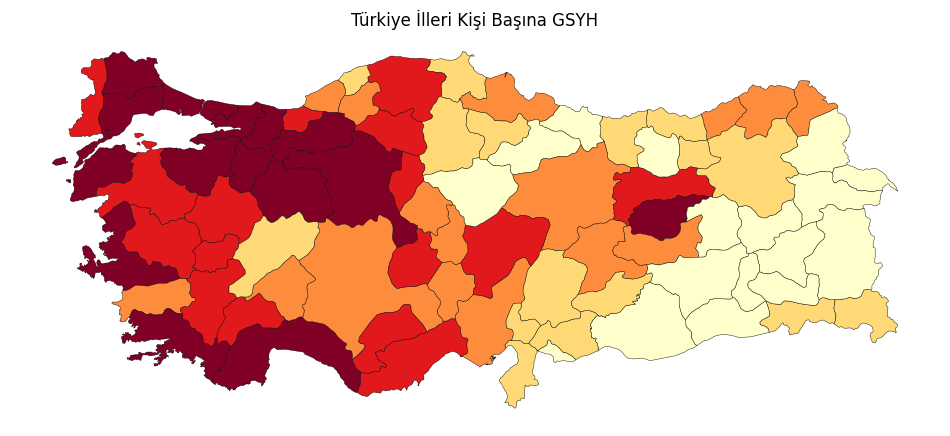

In [70]:
turkey_income.plot(
    column="gsyh_kisi_basi",
    figsize=(12,8),
    cmap="YlOrRd",
    legend=False,
    scheme="quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

plt.title("Türkiye İlleri Kişi Başına GSYH")
plt.axis("off")
plt.show()